In [ ]:
import kagglehub
path = kagglehub.dataset_download("hassaan2580/churn-prediction-gym-members-dataset")

Using Colab cache for faster access to the 'churn-prediction-gym-members-dataset' dataset.


In [ ]:
#welcome
print("hello")

hello


## Defining Stage (Customer Churn Analysis)

###  Problem Definition

The goal of this project is to analyze customer behavior in a gym membership dataset to understand the reasons behind customer churn.

 Objective

The main objective is to reduce customer churn by:

 Identifying the key factors that lead customers to leave
 Predicting which customers are likely to churn

 What is Churn?

Churn refers to customers who stop their subscription or discontinue using the service.

### Dataset Description:

The dataset contains information about gym members, such as:
* Age
* Gender
* Membership type
* Visit frequency
* Subscription details
* Churn status (whether the customer left or stayed)

 Business Questions

 What factors influence customer churn?
 Do less active members tend to leave more?
 Does membership type affect churn?
 Is there a relationship between age and churn?

## Problem Type

This is a classification problem, as we aim to predict whether a customer will churn or not.

## Tools (Optional)

This project will use Python along with libraries such as Pandas and machine learning models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.listdir(path)

['gym_members_dataset.csv']

In [ ]:
import os
import pandas as pd

files=os.listdir(path)
file_name=files[0]
full_path=os.path.join(path,file_name)
df=pd.read_csv(full_path)

In [ ]:
df.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [ ]:
print(f"rows:{df.shape[0]}")
print(f"columns:{df.shape[1]}")


rows:150
columns:15


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

In [ ]:
print(df.isnull().sum())

Member_ID                    0
Name                        23
Age                         13
Gender                       0
Address                      0
Phone_Number                 0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64


In [ ]:
df.columns

Index(['Member_ID', 'Name', 'Age', 'Gender', 'Address', 'Phone_Number',
       'Membership_Type', 'Join_Date', 'Last_Visit_Date', 'Favorite_Exercise',
       'Avg_Workout_Duration_Min', 'Avg_Calories_Burned',
       'Total_Weight_Lifted_kg', 'Visits_Per_Month', 'Churn'],
      dtype='object')

In [ ]:
df.drop(['Member_ID', 'Name','Phone_Number','Address'],axis=1,inplace=True)

In [ ]:
print(df.isnull().sum())

Age                         13
Gender                       0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64


In [ ]:
cols_to_fill=['Age','Avg_Calories_Burned','Total_Weight_Lifted_kg','Visits_Per_Month']
for col in cols_to_fill:
    df[col]=df[col].fillna(df[col].mean())

df.dropna(subset=['Join_Date'],inplace=True)

df['Join_Date']=pd.to_datetime(df['Join_Date'])
df['Last_Visit_Date']=pd.to_datetime(df['Last_Visit_Date'])

print(df.isnull().sum())


Age                         0
Gender                      0
Membership_Type             0
Join_Date                   0
Last_Visit_Date             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
Avg_Calories_Burned         0
Total_Weight_Lifted_kg      0
Visits_Per_Month            0
Churn                       0
dtype: int64


In [ ]:
print(df.describe())

              Age                      Join_Date  \
count  141.000000                            141   
mean    35.460009  2023-06-26 13:37:01.276595712   
min     18.000000            2022-01-09 00:00:00   
25%     26.000000            2022-10-01 00:00:00   
50%     35.905109            2023-07-28 00:00:00   
75%     45.000000            2024-03-17 00:00:00   
max     54.000000            2024-09-23 00:00:00   
std     11.128469                            NaN   

                     Last_Visit_Date  Avg_Workout_Duration_Min  \
count                            141                141.000000   
mean   2023-12-27 20:45:57.446808576                 73.460993   
min              2022-03-20 00:00:00                 30.000000   
25%              2023-04-05 00:00:00                 53.000000   
50%              2024-01-12 00:00:00                 74.000000   
75%              2024-09-24 00:00:00                 95.000000   
max              2025-07-10 00:00:00                118.000000   
std

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Age                       141 non-null    float64       
 1   Gender                    141 non-null    object        
 2   Membership_Type           141 non-null    object        
 3   Join_Date                 141 non-null    datetime64[ns]
 4   Last_Visit_Date           141 non-null    datetime64[ns]
 5   Favorite_Exercise         141 non-null    object        
 6   Avg_Workout_Duration_Min  141 non-null    int64         
 7   Avg_Calories_Burned       141 non-null    float64       
 8   Total_Weight_Lifted_kg    141 non-null    float64       
 9   Visits_Per_Month          141 non-null    float64       
 10  Churn                     141 non-null    object        
dtypes: datetime64[ns](2), float64(4), int64(1), object(4)
memory usage: 13.2+ KB
None


In [ ]:
print (df.isnull().sum())

Age                         0
Gender                      0
Membership_Type             0
Join_Date                   0
Last_Visit_Date             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
Avg_Calories_Burned         0
Total_Weight_Lifted_kg      0
Visits_Per_Month            0
Churn                       0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

In [ ]:
#Preprocessing

In [ ]:
df = pd.get_dummies(df, columns=['Membership_Type'], drop_first=True)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df = pd.get_dummies(df, columns=['Favorite_Exercise'], drop_first=True)

In [ ]:
df.head() #check data

,Age,Gender,Join_Date,Last_Visit_Date,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn,Membership_Type_Quarterly,Membership_Type_Yearly,Favorite_Exercise_Cycling,Favorite_Exercise_Deadlift,Favorite_Exercise_Pull-ups,Favorite_Exercise_Squats,Favorite_Exercise_Treadmill
0,19.0,0,2022-07-23,2022-11-03,93,214.0,13995.0,18.0,0,True,False,False,False,True,False,False
1,19.0,1,2023-12-04,2024-02-14,37,436.0,4612.0,11.0,0,False,False,False,False,False,True,False
2,52.0,0,2024-09-13,2024-12-07,98,523.0,3124.0,4.0,1,True,False,False,False,False,False,False
3,52.0,0,2024-06-05,2025-02-24,66,282.0,4586.0,24.0,0,False,False,False,False,True,False,False
4,32.0,0,2022-06-15,2022-12-02,32,522.0,16353.0,18.0,0,False,False,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Age                          141 non-null    float64       
 1   Gender                       141 non-null    int64         
 2   Join_Date                    141 non-null    datetime64[ns]
 3   Last_Visit_Date              141 non-null    datetime64[ns]
 4   Avg_Workout_Duration_Min     141 non-null    int64         
 5   Avg_Calories_Burned          141 non-null    float64       
 6   Total_Weight_Lifted_kg       141 non-null    float64       
 7   Visits_Per_Month             141 non-null    float64       
 8   Churn                        141 non-null    int64         
 9   Membership_Type_Quarterly    141 non-null    bool          
 10  Membership_Type_Yearly       141 non-null    bool          
 11  Favorite_Exercise_Cycling    141 non-null    bool 

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Join_Date,0
Last_Visit_Date,0
Avg_Workout_Duration_Min,0
Avg_Calories_Burned,0
Total_Weight_Lifted_kg,0
Visits_Per_Month,0
Churn,0
Membership_Type_Quarterly,0


In [ ]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"]) #convert dates

In [ ]:
df["Last_Visit_Date"] = pd.to_datetime(df["Last_Visit_Date"])

In [ ]:
df.describe()

,Age,Gender,Join_Date,Last_Visit_Date,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
count,141.000000,141.000000,141,141,141.000000,141.000000,141.000000,141.000000,141.000000
mean,35.460009,0.489362,2023-06-26 13:37:01.276595712,2023-12-27 20:45:57.446808576,73.460993,489.114138,9576.651433,14.400504,0.248227
min,18.000000,0.000000,2022-01-09 00:00:00,2022-03-20 00:00:00,30.000000,209.000000,1009.000000,4.000000,0.000000
25%,26.000000,0.000000,2022-10-01 00:00:00,2023-04-05 00:00:00,53.000000,359.000000,5895.000000,10.000000,0.000000
50%,35.905109,0.000000,2023-07-28 00:00:00,2024-01-12 00:00:00,74.000000,488.309353,9486.978873,14.224638,0.000000
75%,45.000000,1.000000,2024-03-17 00:00:00,2024-09-24 00:00:00,95.000000,625.000000,13622.000000,19.000000,0.000000
max,54.000000,1.000000,2024-09-23 00:00:00,2025-07-10 00:00:00,118.000000,788.000000,19722.000000,24.000000,1.000000
std,11.128469,0.501669,NaN,NaN,25.714231,162.420529,5060.419931,6.119021,0.433524


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
display(df_encoded.head())

,Age,Gender,Join_Date,Last_Visit_Date,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn,Membership_Type_Quarterly,Membership_Type_Yearly,Favorite_Exercise_Cycling,Favorite_Exercise_Deadlift,Favorite_Exercise_Pull-ups,Favorite_Exercise_Squats,Favorite_Exercise_Treadmill
0,19.0,0,2022-07-23,2022-11-03,93,214.0,13995.0,18.0,0,True,False,False,False,True,False,False
1,19.0,1,2023-12-04,2024-02-14,37,436.0,4612.0,11.0,0,False,False,False,False,False,True,False
2,52.0,0,2024-09-13,2024-12-07,98,523.0,3124.0,4.0,1,True,False,False,False,False,False,False
3,52.0,0,2024-06-05,2025-02-24,66,282.0,4586.0,24.0,0,False,False,False,False,True,False,False
4,32.0,0,2022-06-15,2022-12-02,32,522.0,16353.0,18.0,0,False,False,False,False,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
num_cols = [
    "Age",
    "Avg_Workout_Duration_Min",
    "Avg_Calories_Burned",
    "Total_Weight_Lifted_kg",
    "Visits_Per_Month"
]

In [ ]:
scaler = StandardScaler()

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [ ]:
df_encoded[num_cols].describe()

,Age,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month
count,1.410000e+02,1.410000e+02,1.410000e+02,1.410000e+02,1.410000e+02
mean,3.275552e-16,2.393672e-16,-2.519655e-16,5.984181e-17,-1.889741e-17
std,1.003565e+00,1.003565e+00,1.003565e+00,1.003565e+00,1.003565e+00
min,-1.574543e+00,-1.696179e+00,-1.730771e+00,-1.699107e+00,-1.705760e+00
25%,-8.531034e-01,-7.985437e-01,-8.039501e-01,-7.301324e-01,-7.217154e-01
50%,4.013912e-02,2.103616e-02,-4.972617e-03,-1.778355e-02,-2.884333e-02
75%,8.603162e-01,8.406160e-01,8.396125e-01,8.022596e-01,7.543517e-01
max,1.671936e+00,1.738251e+00,1.846758e+00,2.011991e+00,1.574389e+00


In [ ]:
print(df_encoded.columns)

Index(['Age', 'Gender', 'Join_Date', 'Last_Visit_Date',
       'Avg_Workout_Duration_Min', 'Avg_Calories_Burned',
       'Total_Weight_Lifted_kg', 'Visits_Per_Month', 'Churn',
       'Membership_Type_Quarterly', 'Membership_Type_Yearly',
       'Favorite_Exercise_Cycling', 'Favorite_Exercise_Deadlift',
       'Favorite_Exercise_Pull-ups', 'Favorite_Exercise_Squats',
       'Favorite_Exercise_Treadmill'],
      dtype='object')


### Data visualization


In [ ]:
df.head()

,Age,Gender,Join_Date,Last_Visit_Date,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn,Membership_Type_Quarterly,Membership_Type_Yearly,Favorite_Exercise_Cycling,Favorite_Exercise_Deadlift,Favorite_Exercise_Pull-ups,Favorite_Exercise_Squats,Favorite_Exercise_Treadmill
0,19.0,0,2022-07-23,2022-11-03,93,214.0,13995.0,18.0,0,True,False,False,False,True,False,False
1,19.0,1,2023-12-04,2024-02-14,37,436.0,4612.0,11.0,0,False,False,False,False,False,True,False
2,52.0,0,2024-09-13,2024-12-07,98,523.0,3124.0,4.0,1,True,False,False,False,False,False,False
3,52.0,0,2024-06-05,2025-02-24,66,282.0,4586.0,24.0,0,False,False,False,False,True,False,False
4,32.0,0,2022-06-15,2022-12-02,32,522.0,16353.0,18.0,0,False,False,False,False,False,False,False


<Axes: ylabel='Age'>

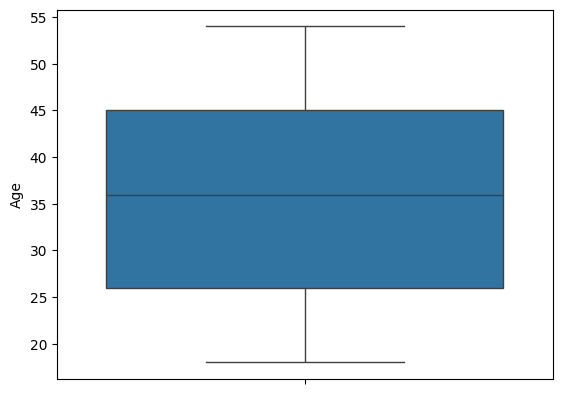

In [ ]:
import seaborn as sns
sns.boxplot(df['Age'])

This graph is a boxplot representing the distribution of member Age.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

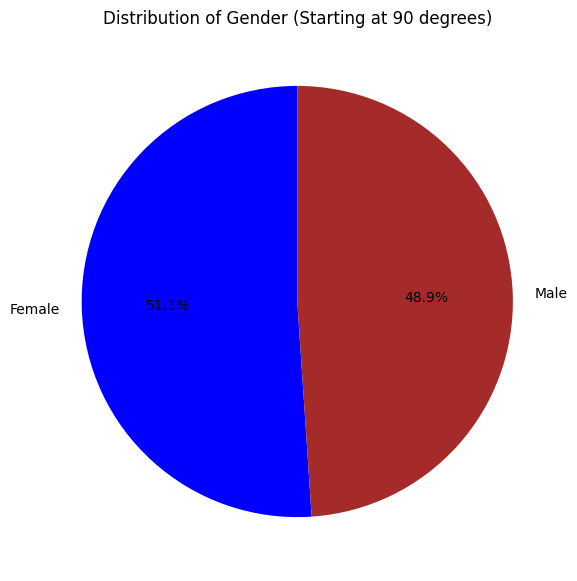

In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each gender
gender_counts = df['Gender'].value_counts()

# Define labels
labels = ['Female' if x == 0 else 'Male' for x in gender_counts.index]

# Create the pie chart with startangle=90
plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['blue', 'brown']
)
plt.title('Distribution of Gender (Starting at 90 degrees)')
plt.show()

"Pie chart" titled "Distribution of Gender (Starting at 90 degrees)," which visualizes the percentage breakdown of people sharing gym membership by gender.

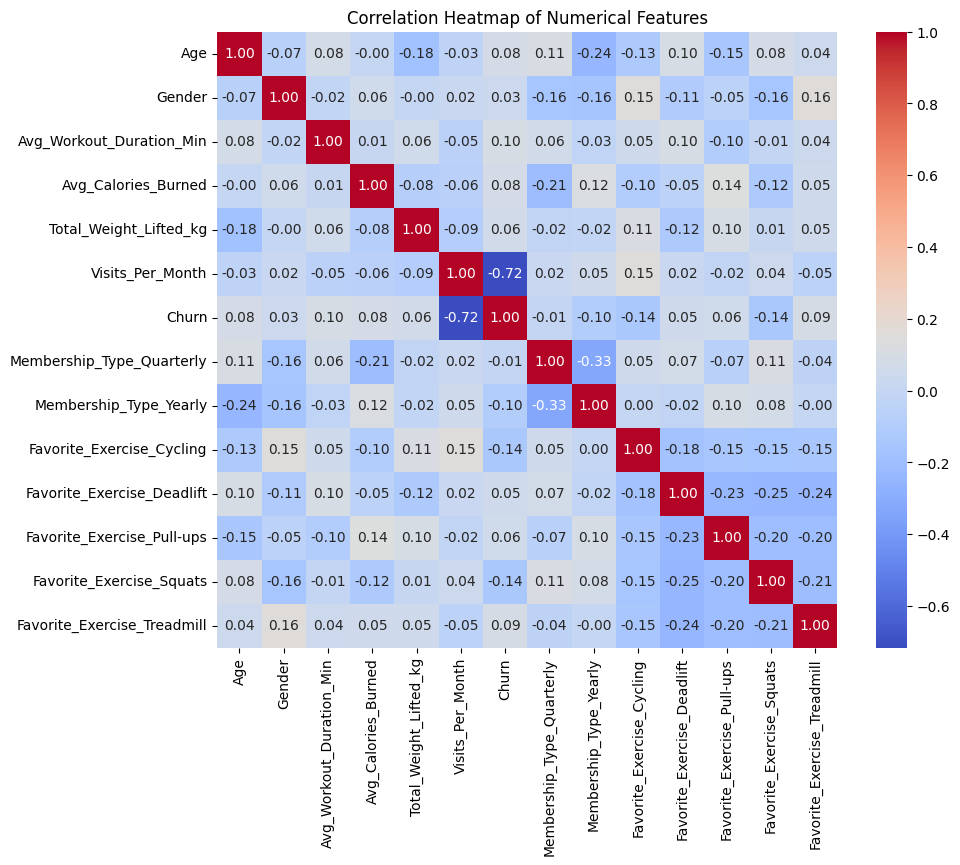

In [ ]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

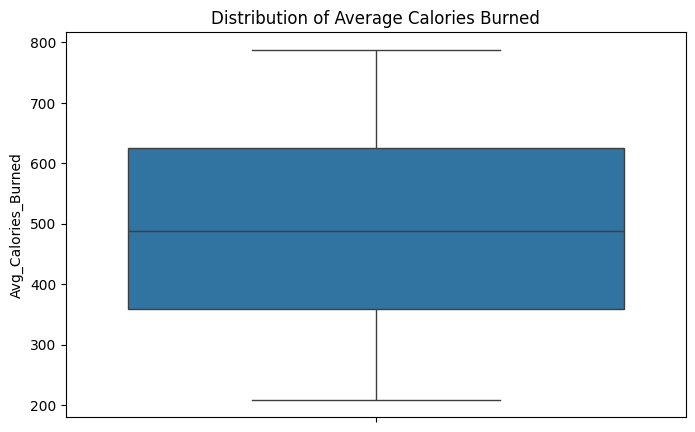

In [ ]:
# Boxplot for Calories Burned
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Avg_Calories_Burned'])
plt.title('Distribution of Average Calories Burned')
plt.show()

This graph is a box plot representing the distribution of Avg_Calories_Burned. It provides a quick summary of how calories burned are spread across the data: This shows that most users burn between roughly 350 and 620 calories on average, with a fairly wide spread across the entire dataset.

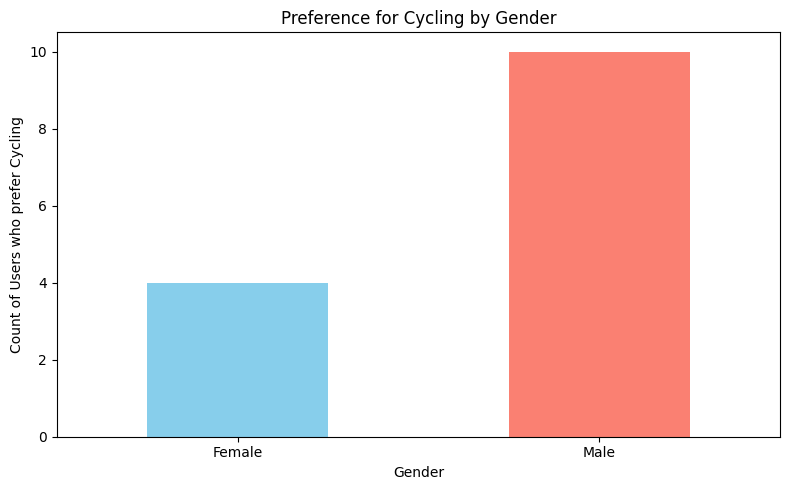

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

gender_map = {0: 'Female', 1: 'Male'}
df['Gender_Label'] = df['Gender'].map(gender_map)


cycling_preference = df.groupby('Gender_Label')['Favorite_Exercise_Cycling'].sum()


cycling_preference.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])


plt.title('Preference for Cycling by Gender')
plt.xlabel('Gender')
plt.ylabel('Count of Users who prefer Cycling')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

This graph illustrates which gender likes cycling more

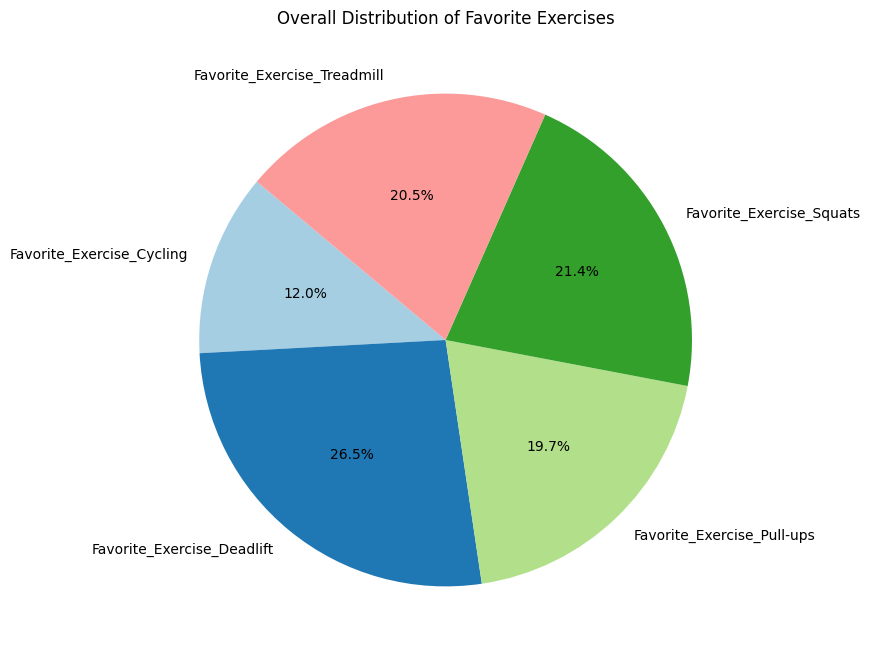

In [ ]:
import matplotlib.pyplot as plt

# 1. Select the exercise columns
exercise_cols = [
    'Favorite_Exercise_Cycling',
    'Favorite_Exercise_Deadlift',
    'Favorite_Exercise_Pull-ups',
    'Favorite_Exercise_Squats',
    'Favorite_Exercise_Treadmill'
]

# 2. Sum the 'True' values (1s) to get the total count for each exercise
exercise_counts = df[exercise_cols].sum()

# 3. Create the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(exercise_counts, labels=exercise_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title('Overall Distribution of Favorite Exercises')
plt.show()

This is a pie chart showing the relationships between different exercise preferences.